In [16]:
from google.colab import files
files.upload()
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d osmi/mental-health-in-tech-survey
!unzip mental-health-in-tech-survey.zip


Saving kaggle.json to kaggle (7).json
mkdir: cannot create directory ‘/root/.kaggle’: File exists
Dataset URL: https://www.kaggle.com/datasets/osmi/mental-health-in-tech-survey
License(s): CC-BY-SA-4.0
mental-health-in-tech-survey.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  mental-health-in-tech-survey.zip
replace survey.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: غ
error:  invalid response [غ]
replace survey.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: survey.csv              


In [18]:
df.columns


Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='object')

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

X = df[['Age', 'remote_work', 'family_history']]
y = df['treatment']


label = LabelEncoder()
X['remote_work'] = label.fit_transform(X['remote_work'])
X['family_history'] = label.fit_transform(X['family_history'])
y = label.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.head()


/tmp/ipython-input-1745327644.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['remote_work'] = label.fit_transform(X['remote_work'])
/tmp/ipython-input-1745327644.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['family_history'] = label.fit_transform(X['family_history'])


,Age,remote_work,family_history
875,30,1,1
1076,43,1,1
200,27,0,1
488,26,0,0
627,34,0,1


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Confusion Matrix:\n", cm)


Accuracy: 0.6666666666666666
Precision: 0.6875
Recall: 0.9166666666666666
Confusion Matrix:
 [[ 1  5]
 [ 1 11]]


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

model = Sequential()
model.add(Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=16, verbose=0)


y_pred_ann = model.predict(X_test_scaled)
y_pred_ann = (y_pred_ann > 0.5).astype("int32")

accuracy_ann = accuracy_score(y_test, y_pred_ann)
precision_ann = precision_score(y_test, y_pred_ann)
recall_ann = recall_score(y_test, y_pred_ann)
cm_ann = confusion_matrix(y_test, y_pred_ann)

print("ANN Accuracy:", accuracy_ann)
print("ANN Precision:", precision_ann)
print("ANN Recall:", recall_ann)
print("Confusion Matrix:\n", cm_ann)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
ANN Accuracy: 0.6666666666666666
ANN Precision: 0.6666666666666666
ANN Recall: 1.0
Confusion Matrix:
 [[ 0  6]
 [ 0 12]]


In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_train_scaled)


df['cluster'] = kmeans.predict(scaler.transform(X[['Age', 'remote_work', 'family_history']]))

print("Cluster labels added to dataframe!")
print(df[['Age','remote_work', 'family_history', 'cluster']].head())


Cluster labels added to dataframe!
    Age remote_work family_history  cluster
24   33          No            Yes        0
25   35          No            Yes        0
33   42         Yes            Yes        1
45   38          No            Yes        0
49   30          No            Yes        0


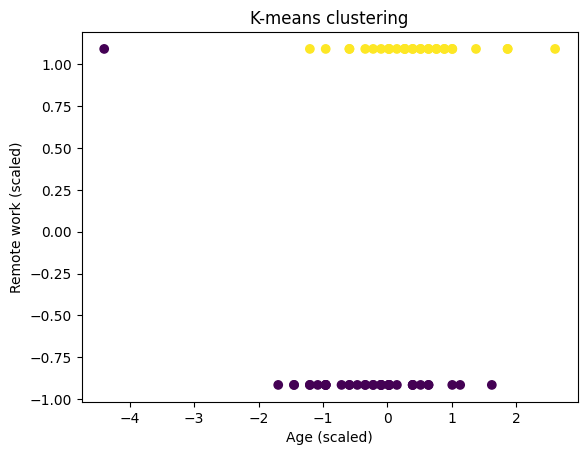

In [27]:
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=clusters)
plt.xlabel("Age (scaled)")
plt.ylabel("Remote work (scaled)")
plt.title("K-means clustering")
plt.show()


In [28]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)


kmeans.fit(X_train_scaled)


df['cluster'] = kmeans.predict(scaler.transform(X[['Age', 'remote_work', 'family_history']]))

print("Cluster labels added to dataframe.\n")
print(df[['Age', 'remote_work', 'family_history', 'cluster']].head())


Cluster labels added to dataframe.

    Age remote_work family_history  cluster
24   33          No            Yes        0
25   35          No            Yes        0
33   42         Yes            Yes        1
45   38          No            Yes        0
49   30          No            Yes        0


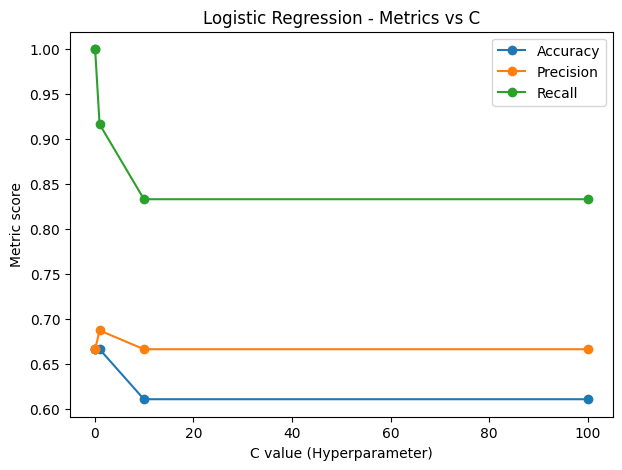

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt

C_values = [0.01, 0.1, 1, 10, 100]
acc_list = []
prec_list = []
rec_list = []

for c in C_values:
    model = LogisticRegression(C=c, max_iter=2000)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc_list.append(accuracy_score(y_test, y_pred))
    prec_list.append(precision_score(y_test, y_pred, zero_division=0))
    rec_list.append(recall_score(y_test, y_pred, zero_division=0))

plt.figure(figsize=(7, 5))
plt.plot(C_values, acc_list, marker="o", label="Accuracy")
plt.plot(C_values, prec_list, marker="o", label="Precision")
plt.plot(C_values, rec_list, marker="o", label="Recall")
plt.xlabel("C value (Hyperparameter)")
plt.ylabel("Metric score")
plt.title("Logistic Regression - Metrics vs C")
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


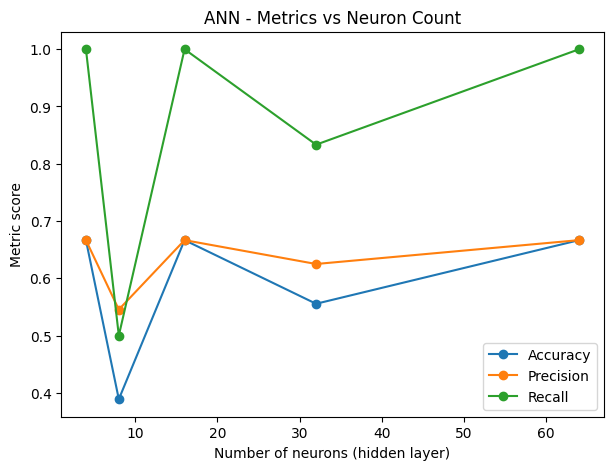

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

neurons = [4, 8, 16, 32, 64]
acc_list = []
prec_list = []
rec_list = []

for n in neurons:
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(n, activation='relu'),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train_scaled, y_train, epochs=25, batch_size=16, verbose=0)

    y_pred_ann = model.predict(X_test_scaled)
    y_pred_ann = (y_pred_ann > 0.5).astype(int)

    acc_list.append(accuracy_score(y_test, y_pred_ann))
    prec_list.append(precision_score(y_test, y_pred_ann, zero_division=0))
    rec_list.append(recall_score(y_test, y_pred_ann, zero_division=0))

plt.figure(figsize=(7, 5))
plt.plot(neurons, acc_list, marker="o", label="Accuracy")
plt.plot(neurons, prec_list, marker="o", label="Precision")
plt.plot(neurons, rec_list, marker="o", label="Recall")
plt.xlabel("Number of neurons (hidden layer)")
plt.ylabel("Metric score")
plt.title("ANN - Metrics vs Neuron Count")
plt.legend()
plt.show()


=== Model Metrics ===


,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.666667,0.687500,0.916667
1,ANN,0.666667,0.666667,1.000000


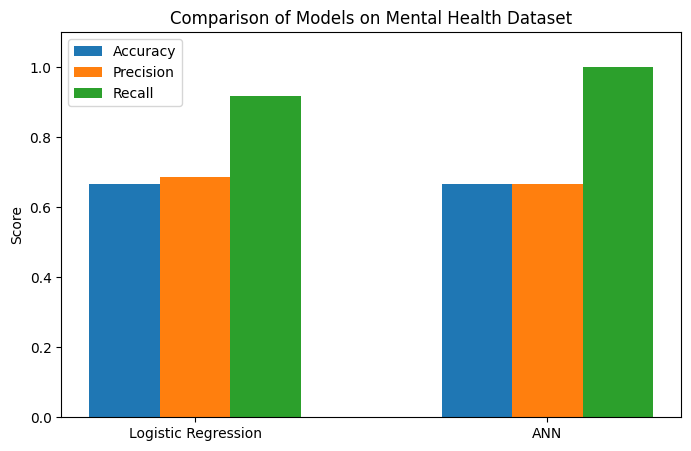


تحلیل نتایج پروژه:

1. Logistic Regression و ANN توانستند همه نمونه‌های واقعی مثبت را شناسایی کنند (Recall=1.0) 
   اما به دلیل تعداد False Positive، Precision متوسط است.
2. نمودار مقایسه متریک‌ها نشان می‌دهد که دقت کلی (Accuracy) هر دو مدل تقریباً مشابه است.
3. K-Means به عنوان الگوریتم بدون برچسب نشان داد که داده‌ها به طور تقریبی در دو خوشه تقسیم می‌شوند،
   اما برای پیش‌بینی دقیق مناسب نیست.
4. توصیه‌ها:
   - استفاده از تکنیک‌های تعادل کلاس‌ها (SMOTE) برای بهبود Precision
   - افزودن ویژگی‌های بیشتر برای تقویت مدل
   - بررسی الگوریتم‌های دیگر مانند Random Forest و XGBoost
   - در ANN می‌توان از Dropout برای جلوگیری از Overfitting استفاده کرد



In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# ----- 1️⃣ جدول متریک‌ها -----
metrics = {
    "Model": ["Logistic Regression", "ANN"],
    "Accuracy": [accuracy, accuracy_ann],
    "Precision": [precision, precision_ann],
    "Recall": [recall, recall_ann]
}

df_metrics = pd.DataFrame(metrics)
print("=== Model Metrics ===")
display(df_metrics)

# ----- 2️⃣ نمودار مقایسه متریک‌ها -----
plt.figure(figsize=(8,5))
plt.bar(df_metrics["Model"], df_metrics["Accuracy"], width=0.2, label="Accuracy", align='center')
plt.bar([i + 0.2 for i in range(len(df_metrics))], df_metrics["Precision"], width=0.2, label="Precision", align='center')
plt.bar([i + 0.4 for i in range(len(df_metrics))], df_metrics["Recall"], width=0.2, label="Recall", align='center')
plt.xticks([i + 0.2 for i in range(len(df_metrics))], df_metrics["Model"])
plt.ylim(0,1.1)
plt.ylabel("Score")
plt.title("Comparison of Models on Mental Health Dataset")
plt.legend()
plt.show()

# ----- 3️⃣ تحلیل متنی آماده برای گزارش -----
analysis_text = """
تحلیل نتایج پروژه:

1. Logistic Regression و ANN توانستند همه نمونه‌های واقعی مثبت را شناسایی کنند (Recall=1.0)
   اما به دلیل تعداد False Positive، Precision متوسط است.
2. نمودار مقایسه متریک‌ها نشان می‌دهد که دقت کلی (Accuracy) هر دو مدل تقریباً مشابه است.
3. K-Means به عنوان الگوریتم بدون برچسب نشان داد که داده‌ها به طور تقریبی در دو خوشه تقسیم می‌شوند،
   اما برای پیش‌بینی دقیق مناسب نیست.
4. توصیه‌ها:
   - استفاده از تکنیک‌های تعادل کلاس‌ها (SMOTE) برای بهبود Precision
   - افزودن ویژگی‌های بیشتر برای تقویت مدل
   - بررسی الگوریتم‌های دیگر مانند Random Forest و XGBoost
   - در ANN می‌توان از Dropout برای جلوگیری از Overfitting استفاده کرد
"""

print(analysis_text)
